In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import scienceplots

In [ ]:
plt.style.use('science')

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['text.usetex'] = False

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
'#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e'
])

# Ex 5

In [ ]:
ex5 = np.loadtxt("/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/ex5.txt", skiprows=1)

ex5_x = ex5[:,0]
ex5_ch1 = ex5[:,1]
ex5_ch2 = ex5[:,2]

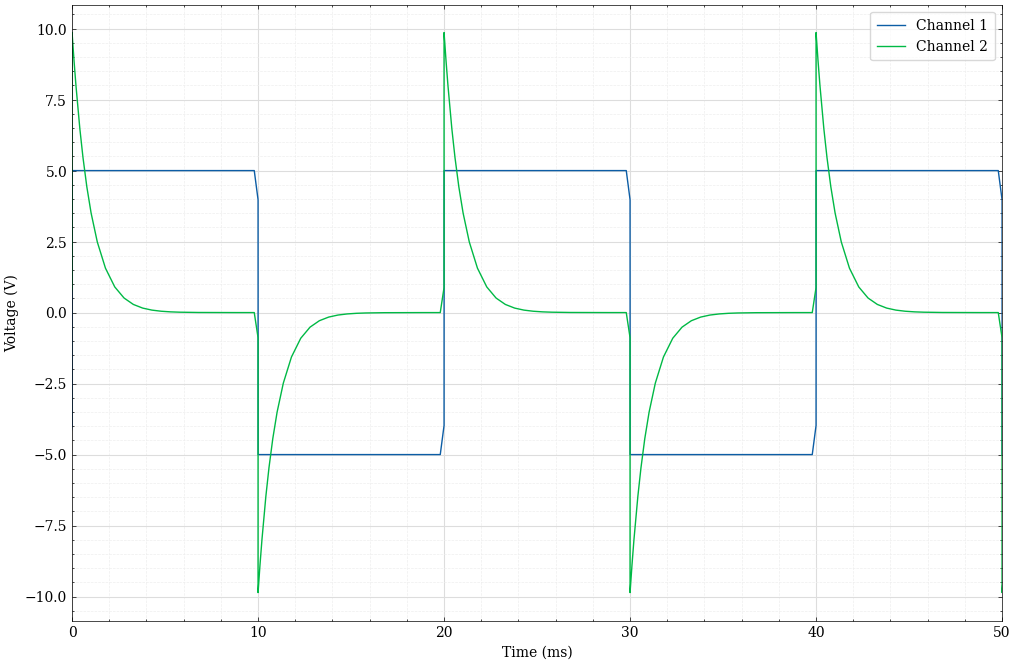

In [ ]:
fig, ax = plt.subplots()

ax.plot(ex5_x * 1e3, ex5_ch1, label='Channel 1')
plt.xlim([0,50])

ax.plot(ex5_x * 1e3, ex5_ch2, label='Channel 2')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')

ax.minorticks_on()
ax.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

ax.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

In [ ]:
ex5 = np.loadtxt("/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/exp5_osl2.txt", skiprows=2)

ex5_x_osc = ex5[:,0]
ex5_ch1_osc = ex5[:,1]
ex5_ch2_osc = ex5[:,2]

In [ ]:
"""
# Add markers to see where indices are
for i in range(0, len(ex5_x_osc), 100):
    plt.text(ex5_x_osc[i]*1e3, ex5_ch2_osc[i], str(i), fontsize=8)
"""

'\n# Add markers to see where indices are\nfor i in range(0, len(ex5_x_osc), 100):\n    plt.text(ex5_x_osc[i]*1e3, ex5_ch2_osc[i], str(i), fontsize=8)\n'

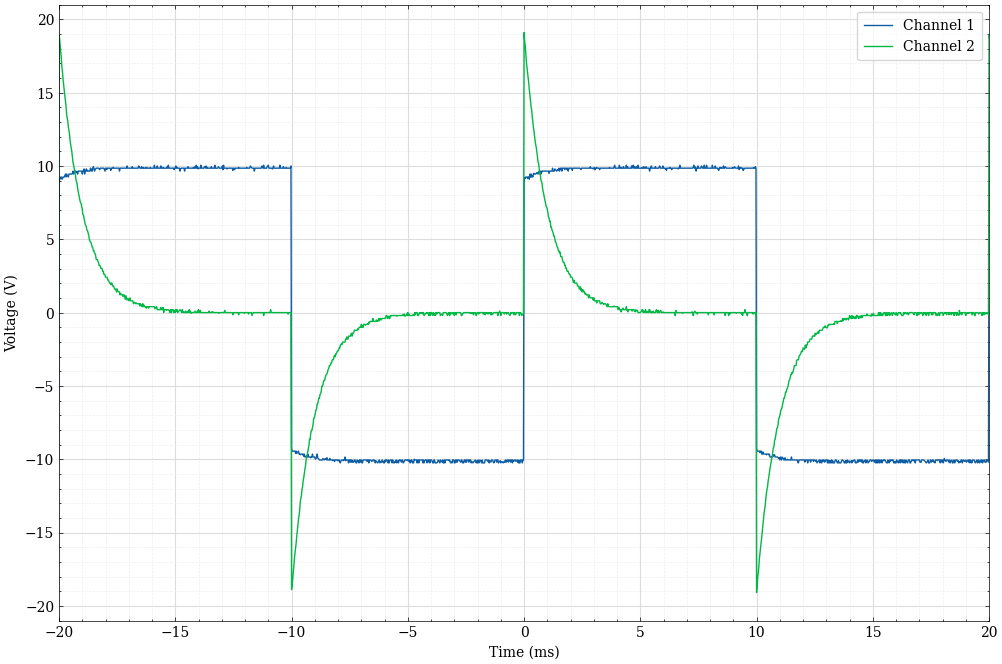

In [ ]:
fig, ax = plt.subplots()

ax.plot(ex5_x_osc * 1e3, ex5_ch1_osc, label='Channel 1')
plt.xlim([-20,20])

ax.plot(ex5_x_osc * 1e3, ex5_ch2_osc, label='Channel 2')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')

ax.minorticks_on()
ax.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

ax.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

In [ ]:
t = ex5_x_osc.copy()
ch1 = ex5_ch1_osc.copy()
ch2 = ex5_ch2_osc.copy()

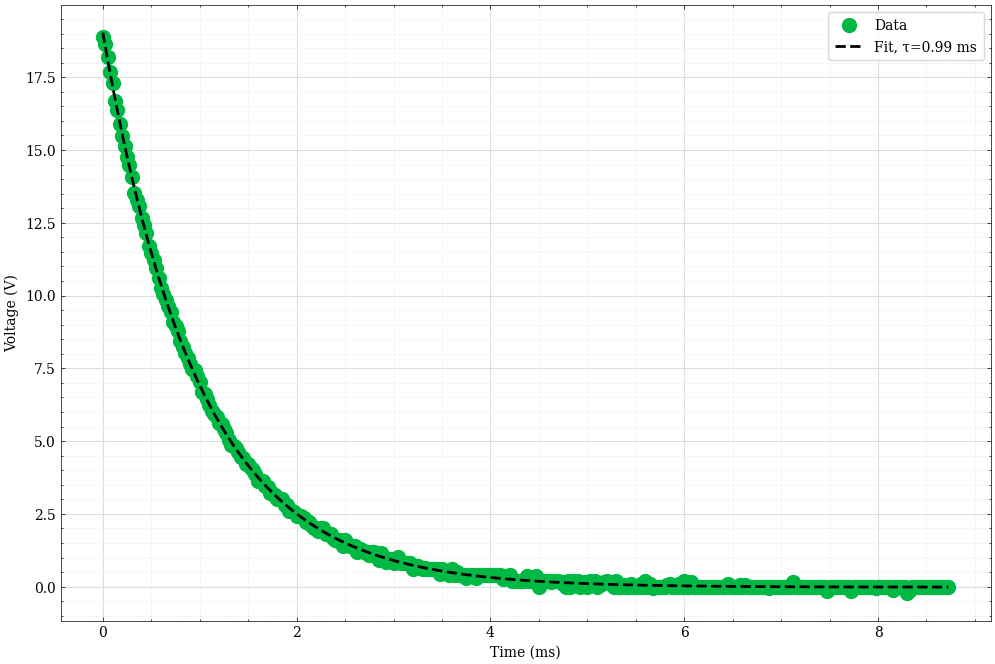

Decay constant τ = 9.8894e-04s  (0.99 ms)


In [ ]:
def exp_model(t, Vinf, A, tau):
    return Vinf - A*np.exp(-t/tau) # Want decay to Vinf, therefore negative sign

start, end = 200, 550   # adjust indices
t_fit = t[start:end] - t[start]
v_fit = ch2[start:end]

p0 = (np.mean(v_fit[-50:]), v_fit[0] - np.mean(v_fit[-50:]), 0.01)
popt, pcov = curve_fit(exp_model, t_fit, v_fit, p0=p0)
Vinf, A, tau = popt

plt.plot(t_fit * 1e3, v_fit, 'o', label='Data', color='#00B945', markersize=10)
plt.plot(t_fit * 1e3, exp_model(t_fit, *popt), '--', label=f'Fit, τ={tau * 1e3:.2f} ms', color='black', linewidth=2)

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

print(f"Decay constant τ = {tau:.4e}s  ({tau*1e3:.2f} ms)")


# Ex 7

In [ ]:
ex7 = np.loadtxt("/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/ex7.txt", skiprows=1)

ex7_freq = ex7[:,0]
ex7_gain = ex7[:,1]
ex7_phase = ex7[:,1]


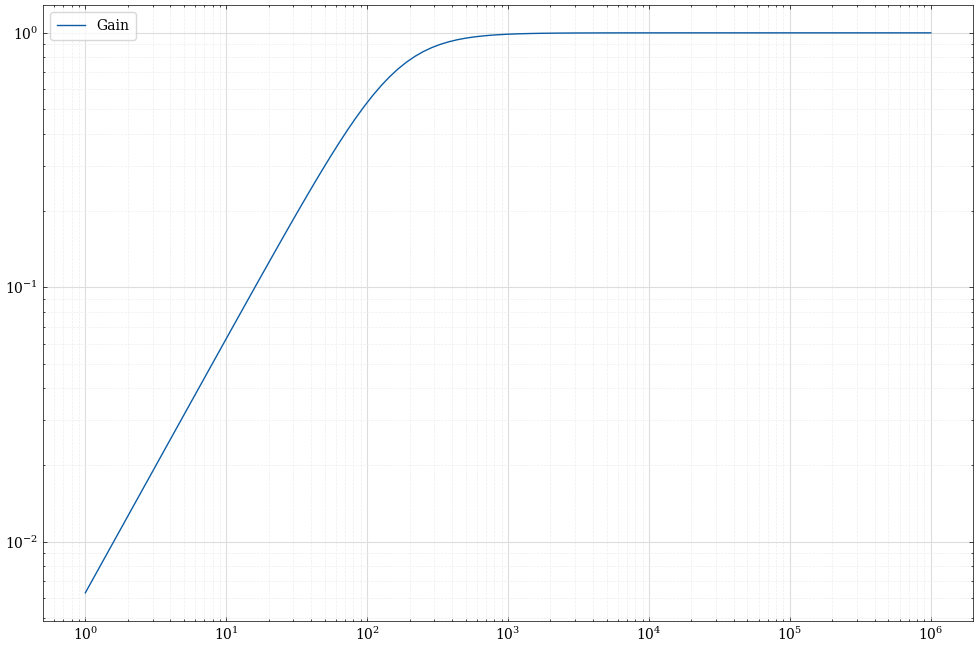

In [ ]:
plt.plot(ex7_freq, ex7_gain, label='Gain')
plt.xscale('log')
plt.yscale('log')

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

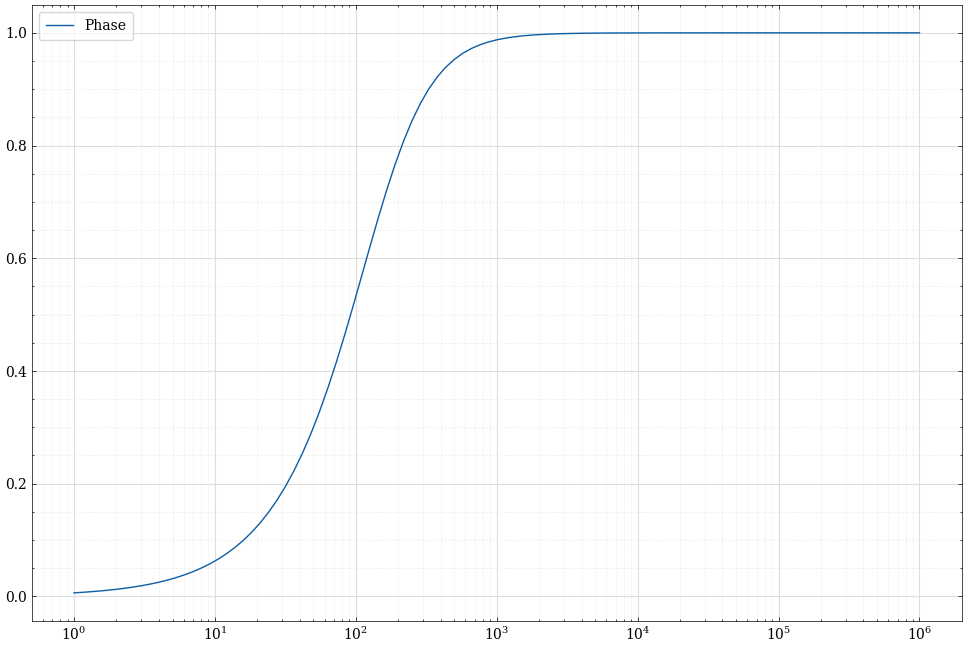

In [ ]:
plt.plot(ex7_freq, ex7_phase, label='Phase')
plt.xscale('log')

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

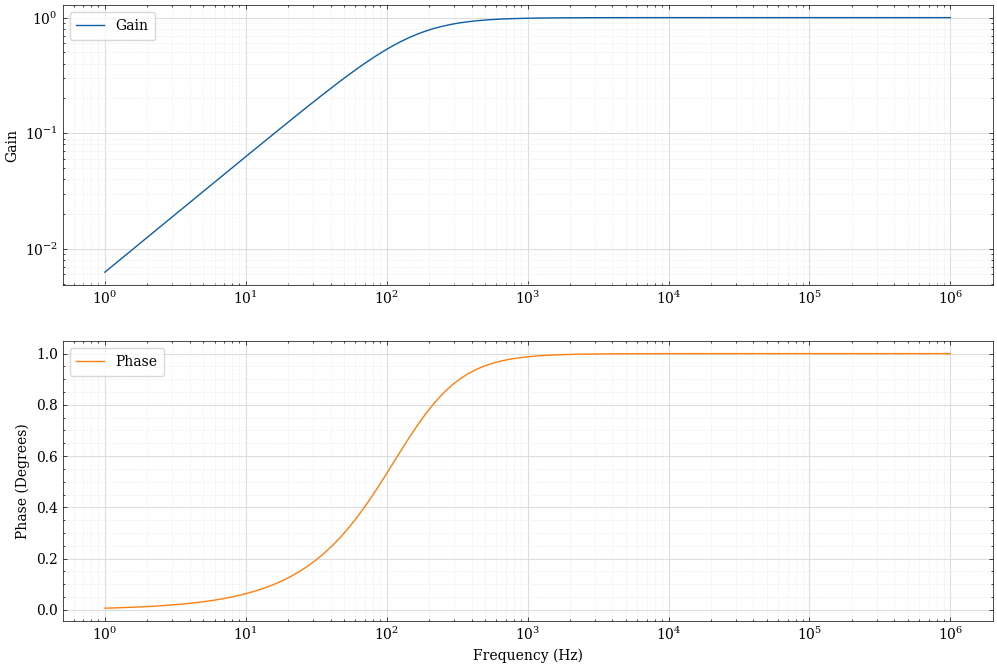

In [ ]:
fig, ax = plt.subplots(2, 1)

ax[0].plot(ex7_freq, ex7_gain, label='Gain')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].minorticks_on()
ax[0].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax[0].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
ax[0].legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)
ax[0].set_ylabel('Gain')

ax[1].plot(ex7_freq, ex7_phase, label='Phase', color='tab:orange')
ax[1].set_xscale('log')

ax[1].minorticks_on()
ax[1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax[1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
ax[1].legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Phase (Degrees)')

plt.show()

In [ ]:
ex7_f = np.array([1, 10, 100, 1000, 10000, 100000, 1000000])
ex7_Vin = np.array([8.52, 1.01, 1.02, 970e-3, 950e-3, 970e-3, 930e-3])
ex7_Vout = np.array([61.1e-3, 61.6e-3, 502e-3, 1, 1.02, 1.02, 907e-3])
ex7_Phase = np.array([87, 84.8, 59.68, 6.95, 0.14, 0.56, 0.9])

ex7_PPhase = 90 - ex7_Phase

ex7_Gain = 20 * np.log10(ex7_Vout / ex7_Vin)

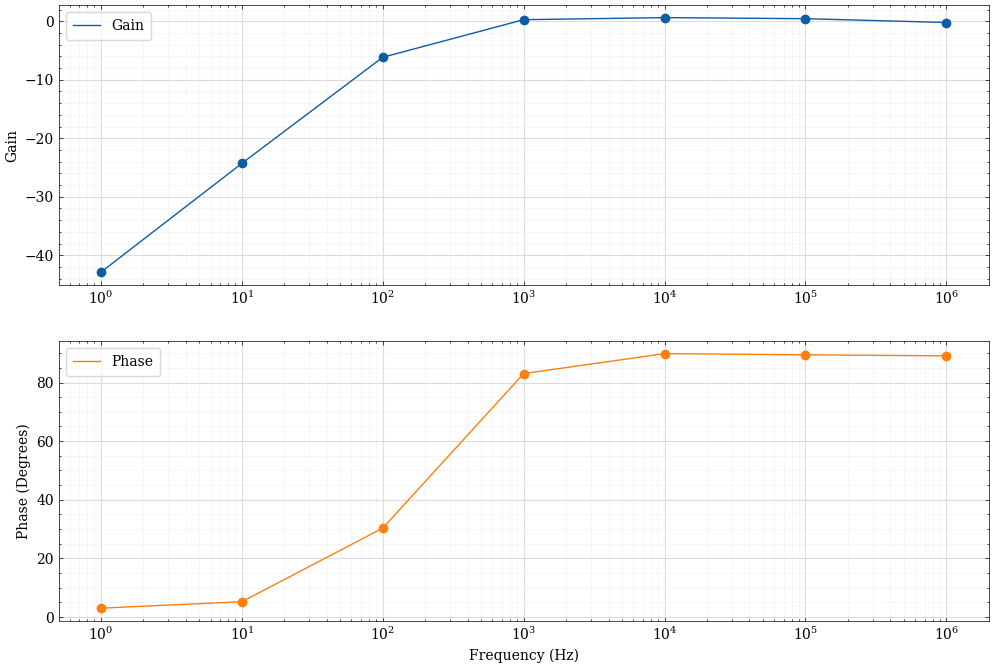

In [ ]:
fig, ax = plt.subplots(2, 1)

ax[0].plot(ex7_f, ex7_Gain, label='Gain')
ax[0].scatter(ex7_f, ex7_Gain, zorder=3)
ax[0].set_xscale('log')
ax[0].minorticks_on()
ax[0].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax[0].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
ax[0].legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)
ax[0].set_ylabel('Gain')

ax[1].plot(ex7_f, ex7_PPhase, label='Phase', color='tab:orange')
ax[1].scatter(ex7_f, ex7_PPhase, color='tab:orange', zorder=3)
ax[1].set_xscale('log')
ax[1].minorticks_on()
ax[1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax[1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
ax[1].legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Phase (Degrees)')

plt.show()

# Ex 12

## a.

### Theory

In [ ]:
ex12a = np.loadtxt("/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/ex12a.txt", skiprows=1)

V_for = ex12a[:,0]
I_for = ex12a[:,1]

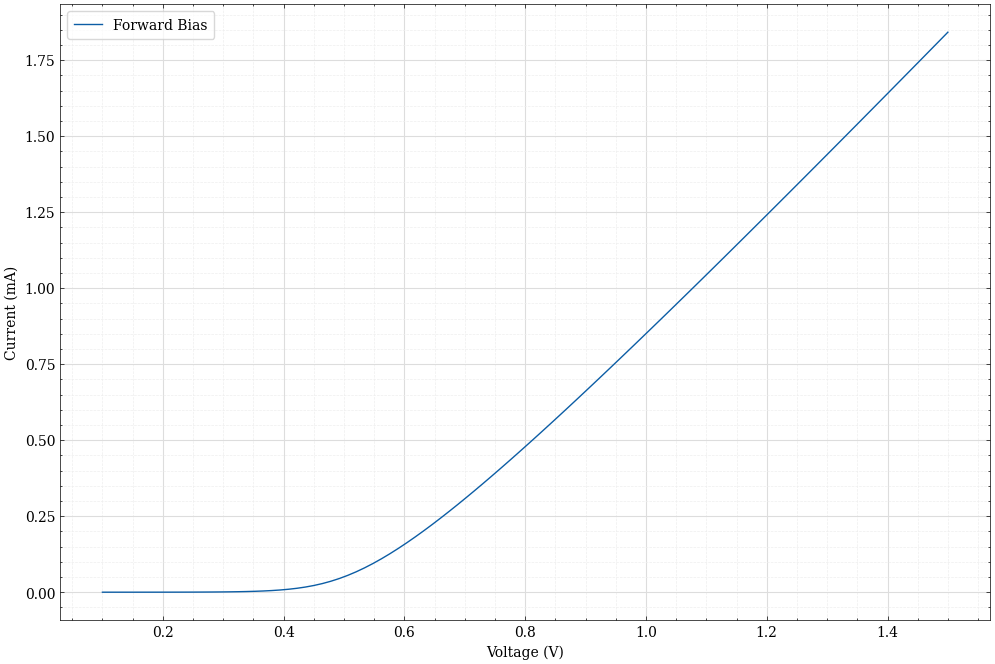

In [ ]:
plt.plot(V_for , I_for *1e3, label='Forward Bias')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (mA)")

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

### Ammeter

In [ ]:
ex12_for_am_V = np.array([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])
ex12_for_am_I = np.array([0,0,0.001,0.006,0.056,0.092,0.202,0.440,0.515,0.683,0.881,1.020,1.143,1.351,1.437,1.683]) 

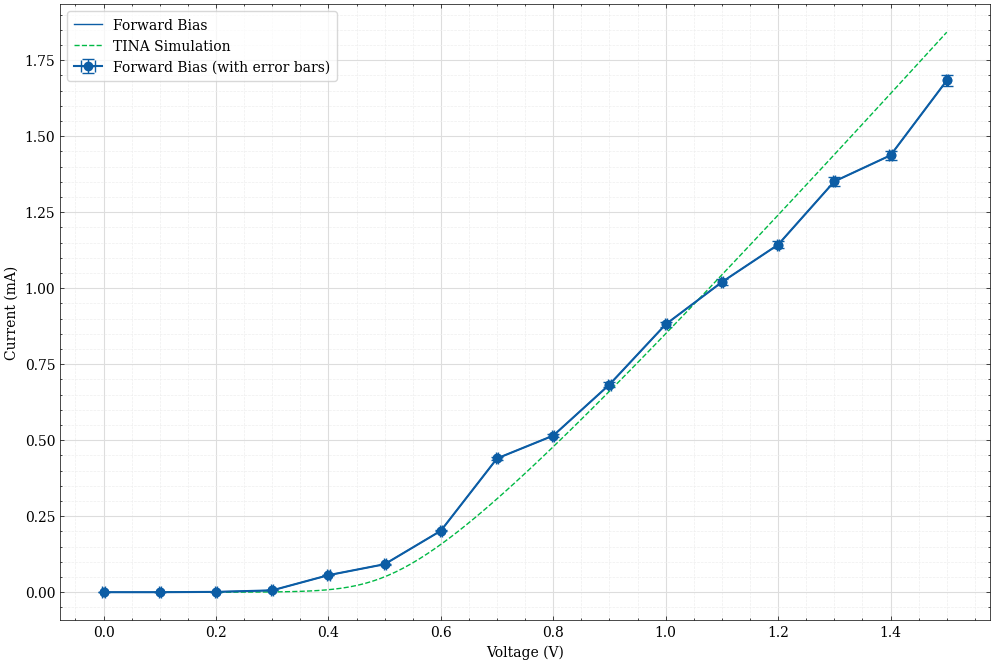

In [ ]:
R = 470 
unc_R = 0.5 * R # 5%, gold band
unc_V = 0.002 # Typical for digital multimeter
unc_I = 0.01 * ex12_for_am_I + 2e-6 # 1% + 2uA

plt.plot(ex12_for_am_V, ex12_for_am_I, label='Forward Bias')
plt.scatter(ex12_for_am_V, ex12_for_am_I, color='#0C5DA5', zorder=3)

plt.errorbar(ex12_for_am_V, ex12_for_am_I, xerr=unc_V, yerr=unc_I, fmt='o-', color='#0C5DA5', markersize=6, linewidth=1.5, capsize=4, capthick=1, elinewidth=1, label='Forward Bias (with error bars)')

plt.plot(V_for , I_for *1e3, label='TINA Simulation', linestyle='--')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (mA)")

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

## b.

### Theory

In [ ]:
ex12b_nocap = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/exp12b.txt', skiprows=1)

ex12b_nocap_time = ex12b_nocap[:,0]
ex12b_nocap_ch1 = ex12b_nocap[:,1]
ex12b_nocap_ch2 = ex12b_nocap[:,2]

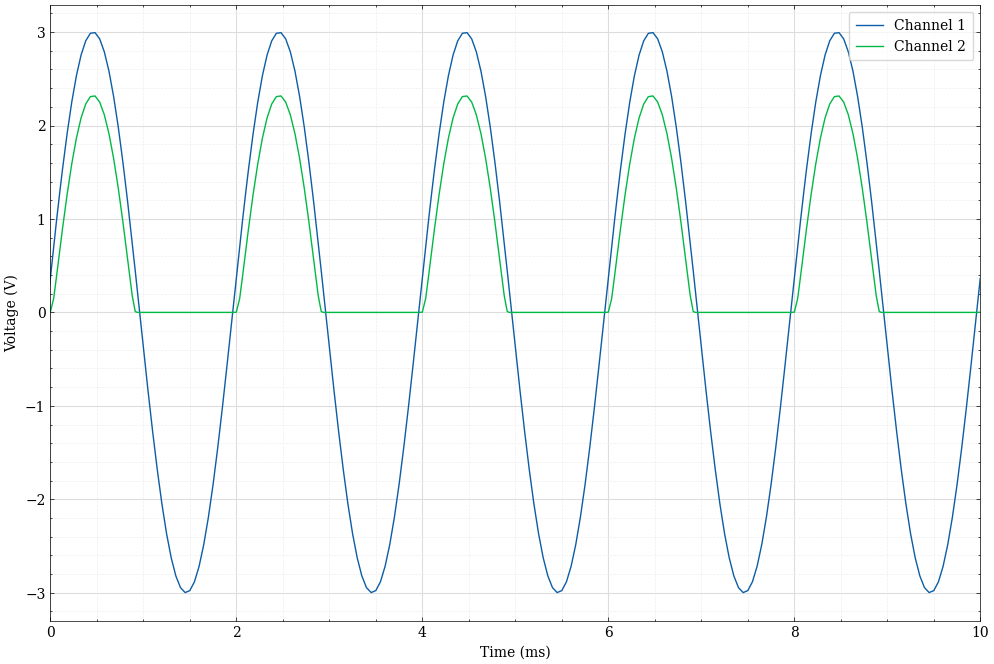

In [ ]:
fig, ax = plt.subplots()

ax.plot(ex12b_nocap_time * 1e3, ex12b_nocap_ch1, label='Channel 1')
plt.xlim([0,10])

ax.plot(ex12b_nocap_time * 1e3, ex12b_nocap_ch2, label='Channel 2')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')

ax.minorticks_on()
ax.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

ax.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

In [ ]:
ex12b_cap = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/exp12b_cap.txt', skiprows=1)

ex12b_cap_time = ex12b_cap[:,0]
ex12b_cap_ch1 = ex12b_cap[:,1]
ex12b_cap_ch2 = ex12b_cap[:,2]

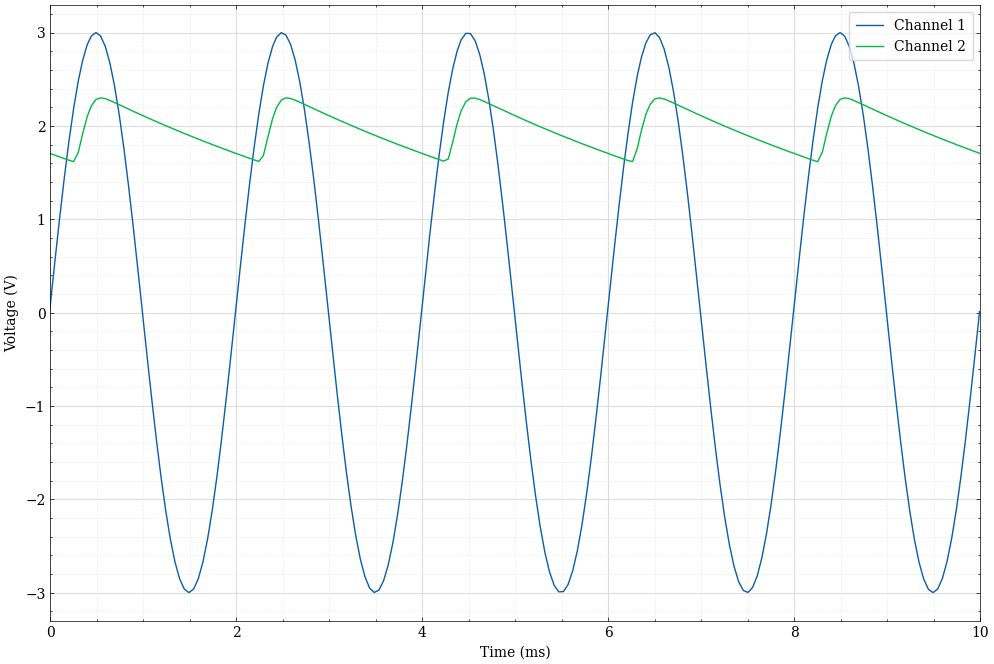

In [ ]:
fig, ax = plt.subplots()

ax.plot(ex12b_cap_time * 1e3, ex12b_cap_ch1, label='Channel 1')
plt.xlim([0,10])

ax.plot(ex12b_cap_time * 1e3, ex12b_cap_ch2, label='Channel 2')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')

ax.minorticks_on()
ax.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

ax.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

### Oscilloscope

In [ ]:
ex12b_nocap_osc = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/osc_ex12b.txt', skiprows=1)

ex12b_nocap_time_osc = ex12b_nocap_osc[:,0]
ex12b_nocap_ch1_osc = ex12b_nocap_osc[:,1]
ex12b_nocap_ch2_osc = ex12b_nocap_osc[:,2]

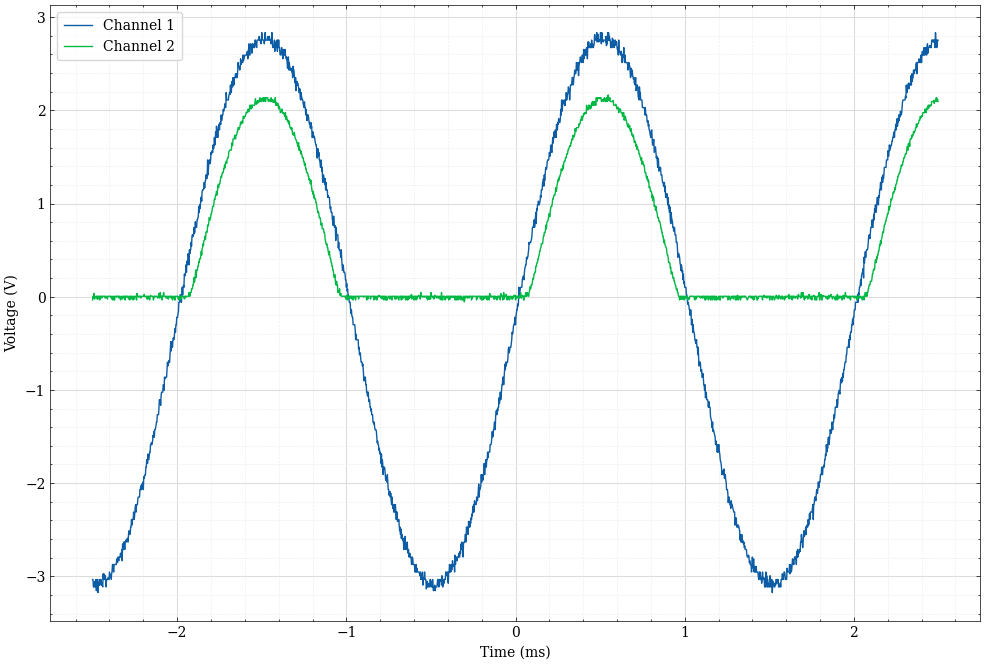

In [ ]:
fig, ax = plt.subplots()

ax.plot(ex12b_nocap_time_osc * 1e3, ex12b_nocap_ch1_osc, label='Channel 1')

ax.plot(ex12b_nocap_time_osc * 1e3, ex12b_nocap_ch2_osc, label='Channel 2')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')

ax.minorticks_on()
ax.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

ax.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

In [ ]:
ex12b_cap_osc = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/osc_ex12b_cap.txt', skiprows=1)

ex12b_cap_time_osc = ex12b_cap_osc[:,0]
ex12b_cap_ch1_osc = ex12b_cap_osc[:,1]
ex12b_cap_ch2_osc = ex12b_cap_osc[:,2]

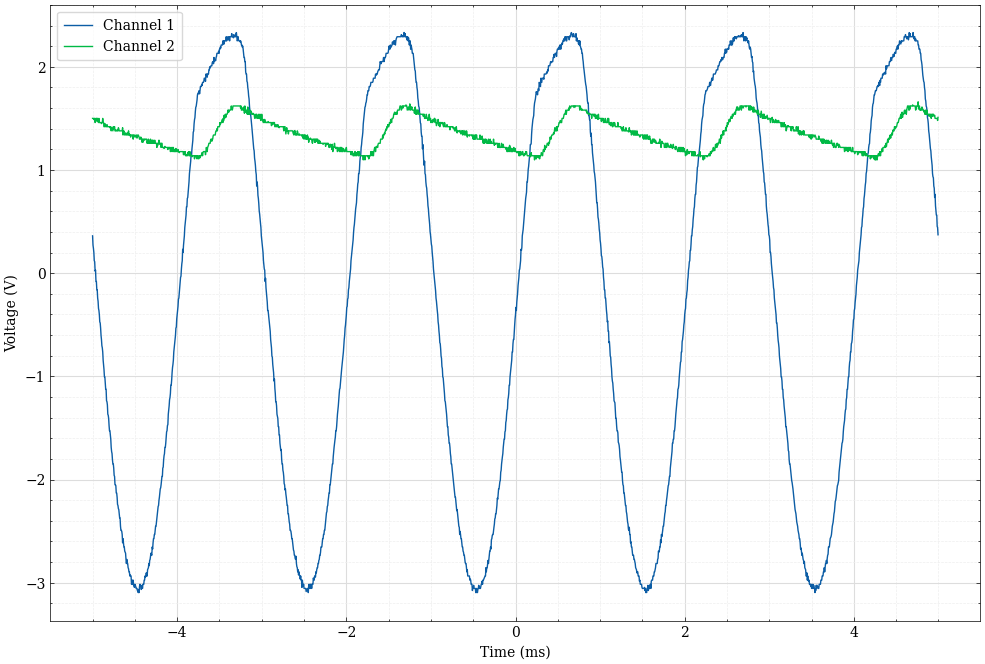

In [ ]:
fig, ax = plt.subplots()

ax.plot(ex12b_cap_time_osc * 1e3, ex12b_cap_ch1_osc, label='Channel 1')

ax.plot(ex12b_cap_time_osc * 1e3, ex12b_cap_ch2_osc, label='Channel 2')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')

ax.minorticks_on()
ax.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

ax.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

# Ex 19

In [ ]:
ex19 = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/ex19.txt', skiprows=1)

input = ex19[:,0]
am1 = ex19[:,1]
am2 = ex19[:,2]

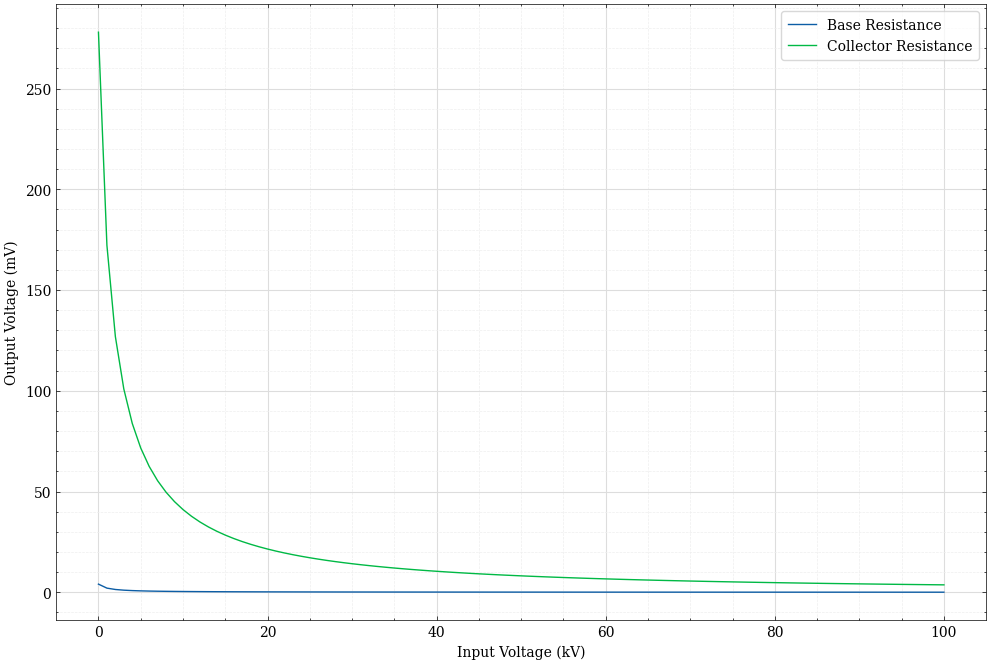

In [ ]:
fig, ax = plt.subplots()

ax.plot(input * 1e-3, am1 * 1e3, label='Base Resistance')

ax.plot(input * 1e-3, am2 * 1e3, label='Collector Resistance')

plt.xlabel('Input Voltage (kV)')
plt.ylabel('Output Voltage (mV)')

ax.minorticks_on()
ax.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

ax.legend(frameon=True, fancybox=True, framealpha=0.75, borderpad=0.5)

plt.show()

# Ex 20

In [ ]:
ex20_r10 = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/ex20_r10.txt', skiprows=1)
ex20_r100 = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/ex20_r100.txt', skiprows=1)
ex20_r1k = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/ex20_r1000.txt', skiprows=1)
ex20_r10k = np.loadtxt('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/labcode_s3/ex20_r10000.txt', skiprows=1)

ex20_input_r10 = ex20_r10[:,0]
ex20_output_r10 = ex20_r10[:,1]
ex20_input_r100 = ex20_r100[:,0]
ex20_output_r100 = ex20_r100[:,1]
ex20_input_r1k = ex20_r1k[:,0]
ex20_output_r1k = ex20_r1k[:,1]
ex20_input_r10k = ex20_r10k[:,0]
ex20_output_r10k = ex20_r10k[:,1]

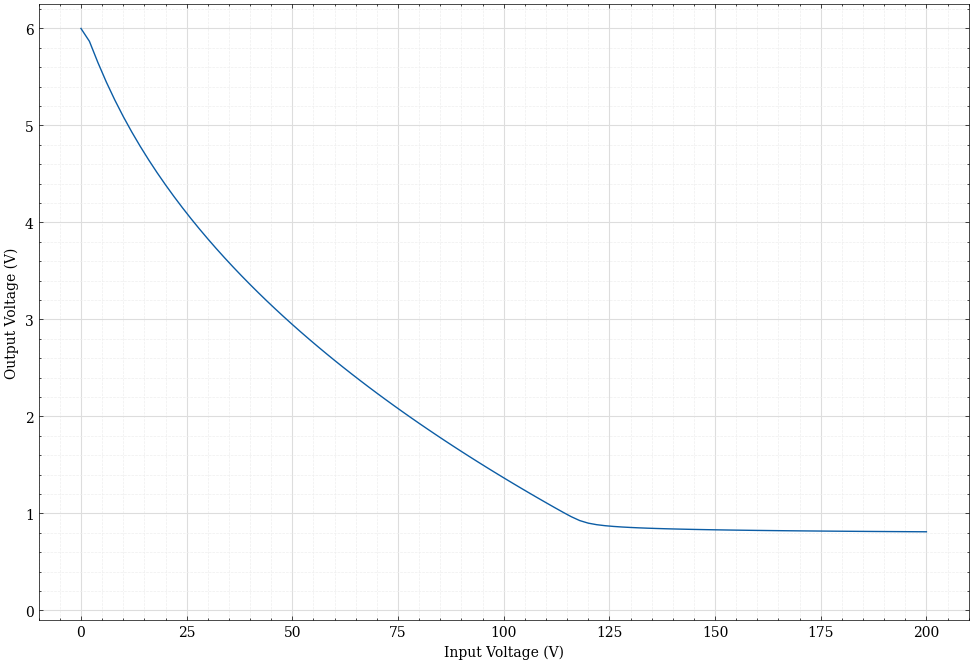

In [ ]:
plt.plot(ex20_input_r10, ex20_output_r10) 

plt.xlabel('Input Voltage (V)') 
plt.ylabel('Output Voltage (V)') 

plt.ylim([-0.1,6.25])

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()

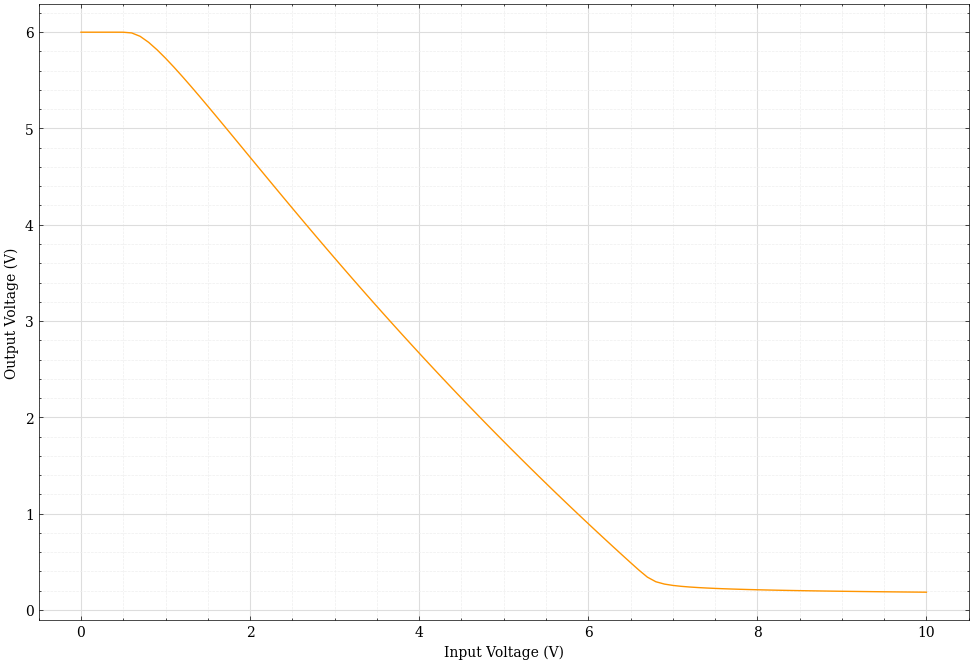

In [ ]:
plt.plot(ex20_input_r100, ex20_output_r100, color='#FF9500') 

plt.xlabel('Input Voltage (V)') 
plt.ylabel('Output Voltage (V)') 

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()

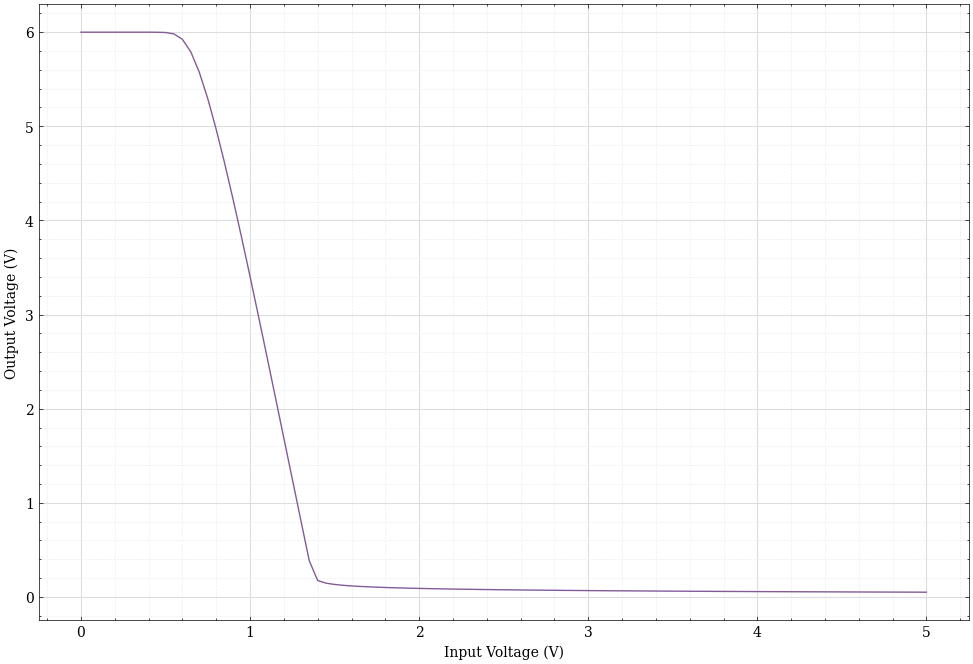

In [ ]:
plt.plot(ex20_input_r1k, ex20_output_r1k, color='#845B97') 

plt.xlabel('Input Voltage (V)') 
plt.ylabel('Output Voltage (V)') 

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()

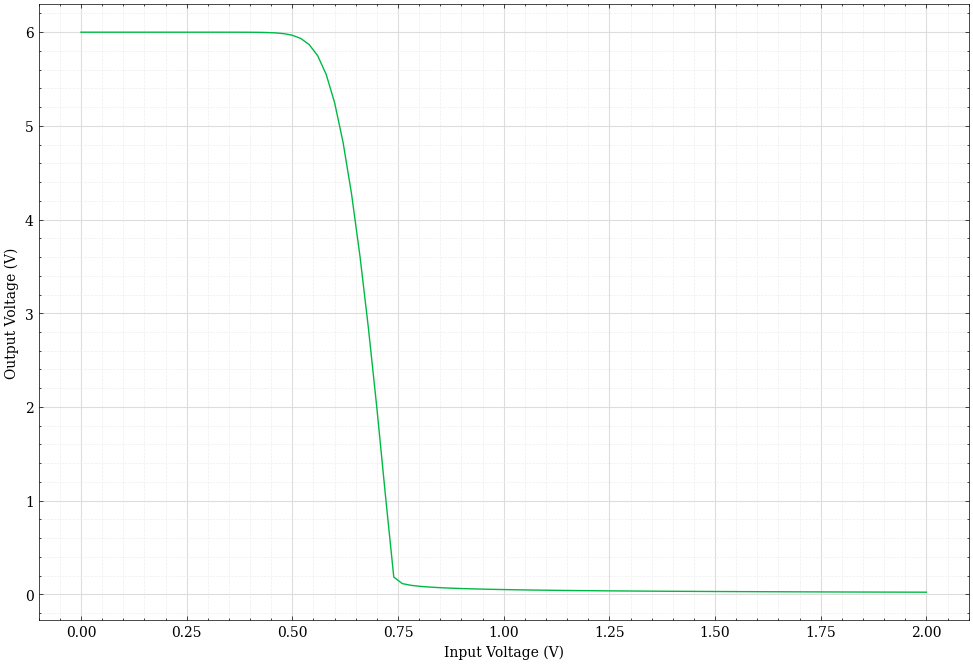

In [ ]:
plt.plot(ex20_input_r10k, ex20_output_r10k, color='#00B945') 

plt.xlabel('Input Voltage (V)') 
plt.ylabel('Output Voltage (V)') 

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()

# Ex 21

# Ex 25

# Ex 27